In [17]:
%load_ext autoreload
%autoreload 2

import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def find_root(marker="setup.py"):
    """
    Find the project root by looking for a marker file.
    If not found in parents of CWD, checks common project subdirectories.
    """
    cwd = Path.cwd().resolve()
    # 1. Check parents of CWD
    for parent in [cwd] + list(cwd.parents):
        if (parent / marker).exists():
            return parent
    
    # 2. Check if we are in a known project structure (e.g. started in home)
    if (cwd / "FOGAS" / marker).exists():
        return cwd / "FOGAS"
        
    # 3. Fallback: try to find FOGAS in parents (if CWD is deep inside but marker is missing)
    for parent in [cwd] + list(cwd.parents):
        if parent.name == "FOGAS":
            return parent
            
    return cwd


PROJECT_ROOT = find_root()
SRC_DIR = PROJECT_ROOT / "src"
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from rl_methods.sbeed.features import (
    IdentityHead,
    NeuralPolicyParam,
    NeuralRhoParam,
    NeuralValueParam,
    StateActionMLPModule,
    StateMLPPolicyModule,
    StateMLPValueModule,
)
from rl_methods.sbeed.solvers import DiscreteSBEED
from rl_methods.sbeed import SBEEDEvaluator

print(DEVICE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
cuda


## MDP

In [2]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
goal_grid = 8

In [3]:
def to_rc(s):
    return divmod(int(s), 3)

def to_s(r, c):
    return r * 3 + c

def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal_grid:
        return goal_grid

    r, c = to_rc(s)

    if a == 0:      # Up
        r = max(0, r - 1)
    elif a == 1:    # Down
        r = min(2, r + 1)
    elif a == 2:    # Left
        c = max(0, c - 1)
    elif a == 3:    # Right
        c = min(2, c + 1)

    return to_s(r, c)

def reward_fn(s, a, sp):
    return 1.0 if int(sp) == goal_grid else -0.1

## Features

In [4]:
value_param = NeuralValueParam(
    module=StateMLPValueModule(
        n_states=N,
        hidden_sizes=(64, 64),
        activation=nn.Tanh,
    ),
)

rho_param = NeuralRhoParam(
    embed_module=StateActionMLPModule(
        n_states=N,
        n_actions=A,
        hidden_sizes=(64, 64),
        output_dim=1,
        activation=nn.Tanh,
    ),
    head_module=IdentityHead(),
)

policy_param = NeuralPolicyParam(
    module=StateMLPPolicyModule(
        n_states=N,
        n_actions=A,
        hidden_sizes=(64, 64),
        activation=nn.Tanh,
    ),
)

## Solving it

In [5]:
solver_sbeed = DiscreteSBEED(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    lambda_entropy=0.01,
    eta=0.01,
    value_param=value_param,
    rho_param=rho_param,
    policy_param=policy_param,

    lr_value=1e-2,
    lr_rho=1e-2,

    lr_policy=1e-3,
    fisher_damping=3e-3,

    cg_iters=10,
    cg_tol=1e-8,

    tau=100000.0,
    max_buffer_size=3000,
    batch_size=64,
    rollout_length=1,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=400,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=50,
    start_state=x_0,
    epsilon=0.1,
    terminal_states={goal_grid},
    log_every=50,
)

episode=50/400 buffer=1050 objective=0.023244 primal_mse=0.023305 dual_mse=0.006116 theta_grad=1.496e-02 policy_grad=1.132e-01
episode=100/400 buffer=2050 objective=0.023812 primal_mse=0.023831 dual_mse=0.001885 theta_grad=5.615e-02 policy_grad=1.702e-01
episode=150/400 buffer=3000 objective=0.022011 primal_mse=0.022021 dual_mse=0.001067 theta_grad=3.543e-02 policy_grad=2.287e-01
episode=200/400 buffer=3000 objective=0.020697 primal_mse=0.020753 dual_mse=0.005643 theta_grad=2.389e-02 policy_grad=2.175e-01
episode=250/400 buffer=3000 objective=0.017971 primal_mse=0.017985 dual_mse=0.001441 theta_grad=2.030e-02 policy_grad=2.740e-01
episode=300/400 buffer=3000 objective=0.015705 primal_mse=0.015715 dual_mse=0.000991 theta_grad=4.367e-02 policy_grad=2.530e-01
episode=350/400 buffer=3000 objective=0.012624 primal_mse=0.012626 dual_mse=0.000240 theta_grad=7.480e-03 policy_grad=3.526e-01
episode=400/400 buffer=3000 objective=0.008858 primal_mse=0.008859 dual_mse=0.000140 theta_grad=4.983e-03

In [6]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.114  pi(1|0)=0.361  pi(2|0)=0.142  pi(3|0)=0.382  --> best action: 3
State 1: pi(0|1)=0.146  pi(1|1)=0.405  pi(2|1)=0.053  pi(3|1)=0.396  --> best action: 1
State 2: pi(0|2)=0.159  pi(1|2)=0.564  pi(2|2)=0.007  pi(3|2)=0.270  --> best action: 1
State 3: pi(0|3)=0.010  pi(1|3)=0.382  pi(2|3)=0.155  pi(3|3)=0.453  --> best action: 3
State 4: pi(0|4)=0.053  pi(1|4)=0.459  pi(2|4)=0.050  pi(3|4)=0.437  --> best action: 1
State 5: pi(0|5)=0.000  pi(1|5)=0.913  pi(2|5)=0.000  pi(3|5)=0.087  --> best action: 1
State 6: pi(0|6)=0.043  pi(1|6)=0.242  pi(2|6)=0.105  pi(3|6)=0.610  --> best action: 3
State 7: pi(0|7)=0.000  pi(1|7)=0.067  pi(2|7)=0.000  pi(3|7)=0.933  --> best action: 3
State 8: pi(0|8)=0.000  pi(1|8)=0.262  pi(2|8)=0.000  pi(3|8)=0.738  --> best action: 3




# Wall and pit

In [14]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0

goal_grid = 8
pit_grid = 5
wall_states = {4}
terminal_states = {goal_grid, pit_grid}

def next_state(s, a):
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = divmod(s, 3)

    if a == 0:      # up
        new_row, new_col = row - 1, col
    elif a == 1:    # down
        new_row, new_col = row + 1, col
    elif a == 2:    # left
        new_row, new_col = row, col - 1
    elif a == 3:    # right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0,1,2,3}")

    if not (0 <= new_row < 3 and 0 <= new_col < 3):
        return s

    sp = new_row * 3 + new_col

    if sp in wall_states:
        return s

    return sp

def reward_fn(s, a, sp):
    if int(sp) == goal_grid:
        return 1.0
    if int(sp) == pit_grid:
        return -1.0
    return -0.1

In [15]:
value_param = NeuralValueParam(
    module=StateMLPValueModule(
        n_states=N,
        hidden_sizes=(64, 64),
        activation=nn.Tanh,
    ),
)

rho_param = NeuralRhoParam(
    embed_module=StateActionMLPModule(
        n_states=N,
        n_actions=A,
        hidden_sizes=(64, 64),
        output_dim=1,
        activation=nn.Tanh,
    ),
    head_module=IdentityHead(),
)

policy_param = NeuralPolicyParam(
    module=StateMLPPolicyModule(
        n_states=N,
        n_actions=A,
        hidden_sizes=(64, 64),
        activation=nn.Tanh,
    ),
)

In [ ]:
solver_sbeed = SBEED(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    lambda_entropy=0.01,
    eta=0.01,
    value_param=value_param,
    rho_param=rho_param,
    policy_param=policy_param,

    lr_value=1e-2,
    lr_rho=1e-2,

    lr_policy=1e-3,
    fisher_damping=3e-3,

    cg_iters=10,
    cg_tol=1e-8,

    tau=100000.0,
    max_buffer_size=3000,
    batch_size=64,
    rollout_length=1,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=800,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=50,
    start_state=x_0,
    epsilon=0.1,
    terminal_states={goal_grid},
    log_every=50,
)

episode=50/800 buffer=1050 objective=0.183793 primal_mse=0.183967 dual_mse=0.017414 theta_grad=1.036e-01 policy_grad=2.541e-01
episode=100/800 buffer=2050 objective=0.142677 primal_mse=0.142881 dual_mse=0.020367 theta_grad=7.985e-02 policy_grad=1.255e+00
episode=150/800 buffer=3000 objective=0.077984 primal_mse=0.078153 dual_mse=0.016845 theta_grad=5.092e-02 policy_grad=1.705e+00
episode=200/800 buffer=3000 objective=0.036159 primal_mse=0.036177 dual_mse=0.001837 theta_grad=3.341e-02 policy_grad=2.166e+00
episode=250/800 buffer=3000 objective=0.008459 primal_mse=0.008460 dual_mse=0.000065 theta_grad=1.291e-02 policy_grad=2.622e+00
episode=300/800 buffer=3000 objective=0.007773 primal_mse=0.007775 dual_mse=0.000151 theta_grad=9.753e-03 policy_grad=1.999e+00
episode=350/800 buffer=3000 objective=0.006992 primal_mse=0.006992 dual_mse=0.000049 theta_grad=2.703e-02 policy_grad=1.564e+00
episode=400/800 buffer=3000 objective=0.006350 primal_mse=0.006351 dual_mse=0.000077 theta_grad=6.980e-03

In [ ]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.138  pi(1|0)=0.786  pi(2|0)=0.076  pi(3|0)=0.000  --> best action: 1
State 1: pi(0|1)=0.203  pi(1|1)=0.237  pi(2|1)=0.560  pi(3|1)=0.000  --> best action: 2
State 2: pi(0|2)=0.000  pi(1|2)=0.000  pi(2|2)=0.992  pi(3|2)=0.008  --> best action: 2
State 3: pi(0|3)=0.000  pi(1|3)=0.897  pi(2|3)=0.038  pi(3|3)=0.065  --> best action: 1
State 4: pi(0|4)=0.001  pi(1|4)=0.000  pi(2|4)=0.000  pi(3|4)=0.999  --> best action: 3
State 5: pi(0|5)=0.394  pi(1|5)=0.606  pi(2|5)=0.000  pi(3|5)=0.000  --> best action: 1
State 6: pi(0|6)=0.000  pi(1|6)=0.001  pi(2|6)=0.004  pi(3|6)=0.996  --> best action: 3
State 7: pi(0|7)=0.000  pi(1|7)=0.000  pi(2|7)=0.000  pi(3|7)=1.000  --> best action: 3
State 8: pi(0|8)=0.000  pi(1|8)=0.000  pi(2|8)=0.001  pi(3|8)=0.998  --> best action: 3




# 5 grid

## Deterministic

In [18]:
states = torch.arange(25, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

grid_size = 5

x_0 = 0

goal_grid = 24
pit_grid = 18

wall_states = {6, 7, 12}
terminal_states = {goal_grid, pit_grid}

def state_to_pos(s):
    s = int(s)
    return divmod(s, grid_size)


def pos_to_state(row, col):
    return row * grid_size + col


def move_deterministic(s, a):
    """
    Deterministic transition used internally.

    This function returns the next state after applying action a.
    It does not return probabilities.
    """
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = state_to_pos(s)

    if a == 0:      # up
        new_row, new_col = row - 1, col
    elif a == 1:    # down
        new_row, new_col = row + 1, col
    elif a == 2:    # left
        new_row, new_col = row, col - 1
    elif a == 3:    # right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0,1,2,3}")

    if not (0 <= new_row < grid_size and 0 <= new_col < grid_size):
        return s

    sp = pos_to_state(new_row, new_col)

    if sp in wall_states:
        return s

    return sp


def transition_probs(s, a):
    """
    Return transition distribution for state-action pair.

    Returns:
        List of (next_state, probability)
    """
    sp = move_deterministic(s, a)
    return [(sp, 1.0)]


def next_state(s, a):
    """
    Sample or select next state.

    For deterministic transitions this just returns the only possible next state.
    This keeps compatibility with your previous code.
    """
    probs = transition_probs(s, a)
    return probs[0][0]


def reward_fn(s, a, sp):
    sp = int(sp)

    if sp == goal_grid:
        return 1.0

    if sp == pit_grid:
        return -1.0

    return -0.1

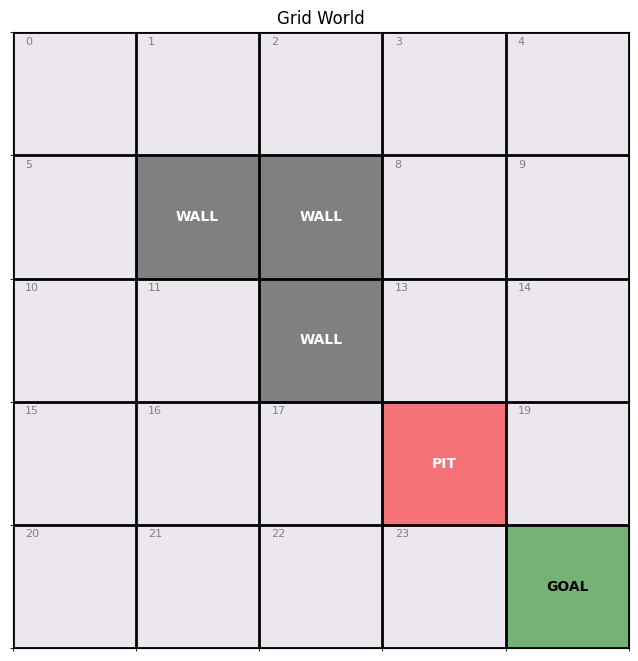

In [19]:
def plot_grid(values=None, policy=None, title="Grid World"):
    """
    Plots the 5x5 grid with environment features.
    
    Args:
        values (torch.Tensor or np.ndarray): Optional 1D array of state values to visualize as colors.
        policy (torch.Tensor or np.ndarray): Optional 2D array [N, A] or 1D array of best actions to show as arrows.
        title (str): Plot title.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Create the background grid
    grid = np.zeros((grid_size, grid_size))
    
    # If values are provided, use them for coloring
    if values is not None:
        if hasattr(values, "detach"): values = values.detach().cpu().numpy()
        grid = values.reshape(grid_size, grid_size)
    
    # Plot the grid
    im = ax.imshow(grid, cmap='viridis', origin='upper', alpha=0.3 if values is not None else 0.1)
    
    # Draw grid lines
    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=2)
    
    for s in range(N):
        r, c = state_to_pos(s)
        
        # Draw Environment Features
        if s == goal_grid:
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='green', alpha=0.5))
            ax.text(c, r, "GOAL", ha='center', va='center', fontweight='bold')
        elif s == pit_grid:
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='red', alpha=0.5))
            ax.text(c, r, "PIT", ha='center', va='center', fontweight='bold', color='white')
        elif s in wall_states:
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='gray'))
            ax.text(c, r, "WALL", ha='center', va='center', fontweight='bold', color='white')
        else:
            # Draw State Index
            ax.text(c-0.4, r-0.4, str(s), fontsize=8, color='gray')
            
            # Draw Value Text
            if values is not None:
                ax.text(c, r, f"{values[s]:.2f}", ha='center', va='center', fontsize=10)

        # Draw Policy Arrows
        if policy is not None:
            if hasattr(policy, "detach"): policy = policy.detach().cpu().numpy()
            
            # If policy is [N, A] (probs), get the argmax
            if len(policy.shape) == 2:
                best_action = np.argmax(policy[s], axis=-1)
            else:
                best_action = policy[s]
                
            if s not in terminal_states and s not in wall_states:
                # 0: up, 1: down, 2: left, 3: right
                dx, dy = 0, 0
                if best_action == 0: dy = -0.3
                elif best_action == 1: dy = 0.3
                elif best_action == 2: dx = -0.3
                elif best_action == 3: dx = 0.3
                
                ax.arrow(c, r, dx, dy, head_width=0.1, head_length=0.1, fc='black', ec='black')

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

# Usage Example:
plot_grid()


In [8]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

value_param = NeuralValueParam(
    module=StateMLPValueModule(
        n_states=N,
        hidden_sizes=(64, 64),
        activation=nn.Tanh,
    ),
)

rho_param = NeuralRhoParam(
    embed_module=StateActionMLPModule(
        n_states=N,
        n_actions=A,
        hidden_sizes=(64, 64),
        output_dim=1,
        activation=nn.Tanh,
    ),
    head_module=IdentityHead(),
)

policy_param = NeuralPolicyParam(
    module=StateMLPPolicyModule(
        n_states=N,
        n_actions=A,
        hidden_sizes=(64, 64),
        activation=nn.Tanh,
    ),
    )

In [11]:
solver_sbeed = DiscreteSBEED(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    eta=0.1,
    value_param=value_param,
    rho_param=rho_param,
    policy_param=policy_param,

    lr_value=1e-4,
    lr_rho=3e-4,
    lr_policy=5e-4,

    lambda_entropy=0.015,
    fisher_damping=2e-3,

    tau=10000.0,
    max_buffer_size=12000,
    batch_size=None,      # full replay batch
    rollout_length=5,     # longer reward propagation

    cg_iters=20,
    cg_tol=1e-8,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=400,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=5000,
    start_state=x_0,
    epsilon=0.3,
    terminal_states={goal_grid, pit_grid},
    log_every=50,
)

episode=50/400 buffer=6000 objective=0.051863 primal_mse=0.053381 dual_mse=0.015174 theta_grad=1.840e-03 policy_grad=2.047e+00
episode=100/400 buffer=7000 objective=0.045750 primal_mse=0.046571 dual_mse=0.008209 theta_grad=6.049e-04 policy_grad=3.110e+00
episode=150/400 buffer=8000 objective=0.043838 primal_mse=0.044439 dual_mse=0.006017 theta_grad=8.294e-04 policy_grad=3.343e+00
episode=200/400 buffer=9000 objective=0.043190 primal_mse=0.043740 dual_mse=0.005501 theta_grad=5.470e-04 policy_grad=3.580e+00
episode=250/400 buffer=10000 objective=0.041347 primal_mse=0.041852 dual_mse=0.005057 theta_grad=7.443e-04 policy_grad=3.730e+00
episode=300/400 buffer=11000 objective=0.041552 primal_mse=0.042105 dual_mse=0.005534 theta_grad=3.047e-04 policy_grad=3.966e+00
episode=350/400 buffer=12000 objective=0.041734 primal_mse=0.042335 dual_mse=0.006010 theta_grad=2.229e-04 policy_grad=4.520e+00
episode=400/400 buffer=12000 objective=0.041116 primal_mse=0.041802 dual_mse=0.006865 theta_grad=1.832

In [13]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.231  pi(1|0)=0.425  pi(2|0)=0.153  pi(3|0)=0.190  --> best action: 1
State 1: pi(0|1)=0.209  pi(1|1)=0.193  pi(2|1)=0.258  pi(3|1)=0.340  --> best action: 3
State 2: pi(0|2)=0.273  pi(1|2)=0.193  pi(2|2)=0.000  pi(3|2)=0.535  --> best action: 3
State 3: pi(0|3)=0.244  pi(1|3)=0.252  pi(2|3)=0.000  pi(3|3)=0.504  --> best action: 3
State 4: pi(0|4)=0.136  pi(1|4)=0.582  pi(2|4)=0.282  pi(3|4)=0.000  --> best action: 1
State 5: pi(0|5)=0.010  pi(1|5)=0.540  pi(2|5)=0.192  pi(3|5)=0.257  --> best action: 1
State 6: pi(0|6)=0.000  pi(1|6)=0.729  pi(2|6)=0.000  pi(3|6)=0.271  --> best action: 1
State 7: pi(0|7)=0.000  pi(1|7)=0.086  pi(2|7)=0.000  pi(3|7)=0.914  --> best action: 3
State 8: pi(0|8)=0.000  pi(1|8)=0.199  pi(2|8)=0.203  pi(3|8)=0.599  --> best action: 3
State 9: pi(0|9)=0.000  pi(1|9)=0.827  pi(2|9)=0.000  pi(3|9)=0.173  --> best action: 1
State 10: pi(0|10)=0.000  pi(1|10)=0.517  pi(2|10)=0.253  pi(3|10)=0.230  --> best 

## Stochastic

In [21]:
def transition_probs(s, a):
    """
    Stochastic transition:
    80% intended action
    20% random action uniformly over all actions.
    """
    s = int(s)
    a = int(a)

    probs_by_state = {}

    for candidate_a in range(A):
        if candidate_a == a:
            prob = 0.8 + 0.2 / A
        else:
            prob = 0.2 / A

        sp = move_deterministic(s, candidate_a)
        probs_by_state[sp] = probs_by_state.get(sp, 0.0) + prob

    return list(probs_by_state.items())

def next_state(s, a):
    probs = transition_probs(s, a)

    next_states = [sp for sp, p in probs]
    probabilities = torch.tensor([p for sp, p in probs], dtype=torch.float)

    idx = torch.multinomial(probabilities, num_samples=1).item()

    return next_states[idx]

In [22]:
solver_sbeed = DiscreteSBEED(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    eta=0.1,
    value_param=value_param,
    rho_param=rho_param,
    policy_param=policy_param,

    # Stochastic gridworld v2
    lr_value=3e-4,
    lr_rho=5e-4,
    lr_policy=4e-4,

    lambda_entropy=0.02,
    fisher_damping=3e-3,

    tau=20000.0,
    max_buffer_size=30000,
    batch_size=None,
    rollout_length=5,

    cg_iters=20,
    cg_tol=1e-8,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=800,
    collect_per_episode=30,
    updates_per_episode=10,
    initial_collect_steps=10000,
    start_state=x_0,
    epsilon=0.3,
    terminal_states={goal_grid, pit_grid},
    log_every=50,
)

episode=50/800 buffer=11500 objective=0.046443 primal_mse=0.047819 dual_mse=0.013755 theta_grad=2.097e-04 policy_grad=3.230e-01
episode=100/800 buffer=13000 objective=0.044796 primal_mse=0.046114 dual_mse=0.013184 theta_grad=1.512e-04 policy_grad=5.702e-01
episode=150/800 buffer=14500 objective=0.042481 primal_mse=0.043982 dual_mse=0.015008 theta_grad=2.077e-04 policy_grad=9.923e-01
episode=200/800 buffer=16000 objective=0.042770 primal_mse=0.044495 dual_mse=0.017254 theta_grad=2.789e-04 policy_grad=1.282e+00
episode=250/800 buffer=17500 objective=0.043380 primal_mse=0.045180 dual_mse=0.018001 theta_grad=1.229e-03 policy_grad=1.406e+00
episode=300/800 buffer=19000 objective=0.043960 primal_mse=0.045757 dual_mse=0.017976 theta_grad=2.636e-03 policy_grad=1.499e+00
episode=350/800 buffer=20500 objective=0.045175 primal_mse=0.047154 dual_mse=0.019784 theta_grad=2.009e-03 policy_grad=1.541e+00
episode=400/800 buffer=22000 objective=0.046307 primal_mse=0.048291 dual_mse=0.019837 theta_grad=4

In [24]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.285  pi(1|0)=0.251  pi(2|0)=0.140  pi(3|0)=0.323  --> best action: 3
State 1: pi(0|1)=0.216  pi(1|1)=0.192  pi(2|1)=0.109  pi(3|1)=0.484  --> best action: 3
State 2: pi(0|2)=0.234  pi(1|2)=0.138  pi(2|2)=0.000  pi(3|2)=0.628  --> best action: 3
State 3: pi(0|3)=0.187  pi(1|3)=0.513  pi(2|3)=0.000  pi(3|3)=0.300  --> best action: 1
State 4: pi(0|4)=0.203  pi(1|4)=0.694  pi(2|4)=0.000  pi(3|4)=0.103  --> best action: 1
State 5: pi(0|5)=0.112  pi(1|5)=0.443  pi(2|5)=0.247  pi(3|5)=0.198  --> best action: 1
State 6: pi(0|6)=0.000  pi(1|6)=0.910  pi(2|6)=0.000  pi(3|6)=0.090  --> best action: 1
State 7: pi(0|7)=0.000  pi(1|7)=0.322  pi(2|7)=0.000  pi(3|7)=0.678  --> best action: 3
State 8: pi(0|8)=0.000  pi(1|8)=0.251  pi(2|8)=0.025  pi(3|8)=0.723  --> best action: 3
State 9: pi(0|9)=0.000  pi(1|9)=0.927  pi(2|9)=0.000  pi(3|9)=0.073  --> best action: 1
State 10: pi(0|10)=0.000  pi(1|10)=0.398  pi(2|10)=0.315  pi(3|10)=0.287  --> best 